In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# SVM with Quadratic (Non-linear) Dataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
# Generate random data
np.random.seed(42)

X = np.random.uniform(-3, 3, (300, 2))

# Quadratic decision boundary
y = (X[:,1] > X[:,0]**2 - 1).astype(int)

# Train SVM with RBF Kernel
model = SVC(kernel='rbf', gamma='scale')
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

In [4]:
# Accuracy
print("Accuracy:", accuracy_score(y, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y, y_pred))

print("\nClassification Report")
print(classification_report(y, y_pred))

Accuracy: 0.98

Confusion Matrix
[[227   1]
 [  5  67]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       228
           1       0.99      0.93      0.96        72

    accuracy                           0.98       300
   macro avg       0.98      0.96      0.97       300
weighted avg       0.98      0.98      0.98       300



In [5]:
# Plot decision boundary
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

In [6]:
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

In [7]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

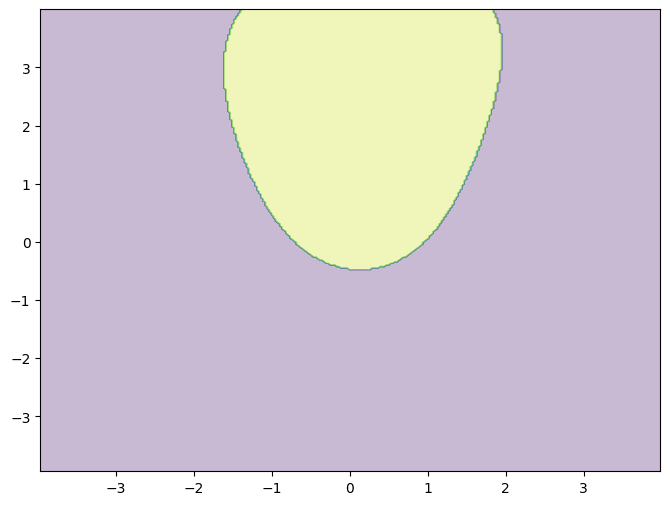

In [8]:
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

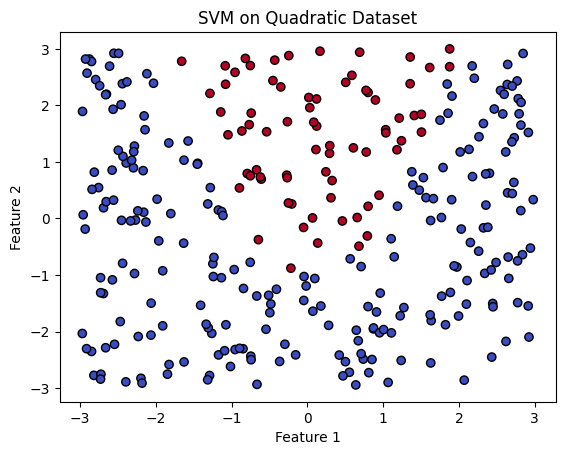

In [9]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("SVM on Quadratic Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()